In [9]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.measure import shannon_entropy as entropy
from skimage.feature import graycomatrix, graycoprops
from skimage import img_as_ubyte

In [10]:
def calcular_entropia(imagen):
    """Retorna la entropía de Shannon de la imagen (float)."""
    return entropy(imagen)

def calcular_homogeneidad(imagen):
    """
    Calcula la homogeneidad a partir de la GLCM (gray level co-occurrence matrix).
    Devuelve un float.
    """
    img_u8 = img_as_ubyte(imagen)
    glcm = graycomatrix(
        img_u8,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )
    return graycoprops(glcm, 'homogeneity')[0, 0]

In [13]:
pwd

'D:\\Folder_Jupiter\\Analisis_Espectros\\Depuracion_Bump_Morlet'

In [103]:
representaciones = [
    "DataSetImages/Spectrograms/Mel-512",
    "DataSetImages/Spectrograms/Mel-1024",
    "DataSetImages/Spectrograms/Mel-2048",
    "DataSetImages/Scalograms/Bump",
    "DataSetImages/Scalograms/Morlet"
]
clases = [
    "air_conditioner",
    "children_playing",
    "drilling",
    "engine_idling",
    "jackhammer",
    "siren",
    "street_music"
]

In [104]:
for ruta_repr in representaciones:
    repr_name = os.path.basename(ruta_repr)
    print(repr_name)

Mel-512
Mel-1024
Mel-2048
Bump
Morlet


In [105]:
for ruta_repr in representaciones:
    ruta_completa = os.path.join(ruta_repr,)
    print(f"Verificando: {ruta_completa} -> {os.path.exists(ruta_completa)}")

Verificando: DataSetImages/Spectrograms/Mel-512 -> True
Verificando: DataSetImages/Spectrograms/Mel-1024 -> True
Verificando: DataSetImages/Spectrograms/Mel-2048 -> True
Verificando: DataSetImages/Scalograms/Bump -> True
Verificando: DataSetImages/Scalograms/Morlet -> True


In [107]:
records = []

for ruta_repr in representaciones:
    repr_name = os.path.basename(ruta_repr)
    print(f"🔍 Procesando representación: {repr_name}")
    for clase in clases:
        carpeta = os.path.join(ruta_repr, clase)
        imagenes = os.listdir(carpeta)[:]  # primeros 100 para prueba
        for fname in imagenes:
             if fname.lower().endswith('.png'):
                img = imread(os.path.join(carpeta, fname), as_gray=True)
                records.append({
                    'representacion': repr_name,
                    'clase': clase,
                    'filename': fname,
                    'entropia': calcular_entropia(img),
                    'homogeneidad': calcular_homogeneidad(img)
                })

df = pd.DataFrame(records)
print(f"\nTotal de imágenes procesadas: {len(df)}")

🔍 Procesando representación: Mel-512
🔍 Procesando representación: Mel-1024
🔍 Procesando representación: Mel-2048
🔍 Procesando representación: Bump
🔍 Procesando representación: Morlet

Total de imágenes procesadas: 26810


In [13]:
resumen = df.groupby(
    ['representacion', 'clase']
)[['entropia', 'homogeneidad']].agg(['min', 'max', 'mean', 'std'])
display(resumen)

entropia                                 \
                                      min        max      mean       std   
representacion clase                                                       
Bump           air_conditioner   0.466923   8.285187  4.498955  1.506819   
               children_playing  0.241702   7.593844  3.197257  1.280699   
               drilling          1.791381  10.049511  6.028943  1.912159   
               engine_idling     0.250700   9.472023  4.123787  2.006260   
               jackhammer        1.766023   8.173310  5.479214  1.236075   
               siren             0.581912   7.106318  2.847228  1.350132   
               street_music      0.302776   8.134089  3.689550  1.451475   
Mel-1024       air_conditioner   6.543995   7.795119  7.343334  0.275369   
               children_playing  6.220584   7.807668  7.425809  0.226780   
               drilling          5.586572   7.790249  7.126444  0.422043   
               engine_idling     5.995060   7.812371  7.438608  0.235879   
               jackhammer        5.765321   7.813102  7.315930  0.315590   
               siren             6.231528   7.832831  7.466410  0.257117   
               street_music      6.378071   7.834579  7.452507  0.291175   
Mel-2048       air_conditioner   6.513062   7.813700  7.320656  0.288934   
               children_playing  6.124243   7.820914  7.419644  0.242952   
               drilling          5.555221   7.814028  7.113815  0.429708   
               engine_idling     6.004785   7.805099  7.416430  0.242359   
               jackhammer        5.690007   7.836804  7.294975  0.326574   
               siren             6.205849   7.819411  7.442824  0.279127   
               street_music      6.322814   7.846162  7.439628  0.306704   
Mel-512        air_conditioner   6.569984   7.786520  7.357539  0.257059   
               children_playing  6.325035   7.786753  7.434642  0.209017   
               drilling          5.622515   7.785267  7.115042  0.423938   
               engine_idling     6.043451   7.813171  7.446415  0.229695   
               jackhammer        5.866484   7.803663  7.317535  0.307949   
               siren             6.252098   7.833078  7.488613  0.233865   
               street_music      6.413881   7.837486  7.464995  0.274582   
Morlet         air_conditioner   0.416753   9.021822  5.344276  1.600004   
               children_playing  0.499419   8.231234  4.263747  1.386649   
               drilling          2.615278  10.084995  7.083901  1.720433   
               engine_idling     0.404494   9.768543  4.983941  2.050797   
               jackhammer        2.068629   8.855205  6.492354  1.227514   
               siren             1.233956   7.864941  4.054547  1.377741   
               street_music      0.291476   9.337185  4.760799  1.561471   

                                homogeneidad                                
                                         min       max      mean       std  
representacion clase                                                        
Bump           air_conditioner      0.278600  0.977271  0.635793  0.146212  
               children_playing     0.215728  0.986535  0.760343  0.123708  
               drilling             0.124607  0.898521  0.503243  0.206597  
               engine_idling        0.124049  0.988883  0.622699  0.239114  
               jackhammer           0.106413  0.894261  0.510114  0.175614  
               siren                0.395987  0.975460  0.810729  0.120499  
               street_music         0.173829  0.988958  0.735295  0.143990  
Mel-1024       air_conditioner      0.093631  0.286677  0.179888  0.039792  
               children_playing     0.103123  0.789186  0.183676  0.066068  
               drilling             0.083282  0.694211  0.202637  0.117735  
               engine_idling        0.067518  0.394214  0.156443  0.041940  
               jackhammer           0.053351  0.410725  0.140048  

c:\Users\pablo\miniconda3\envs\mi_entorno\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


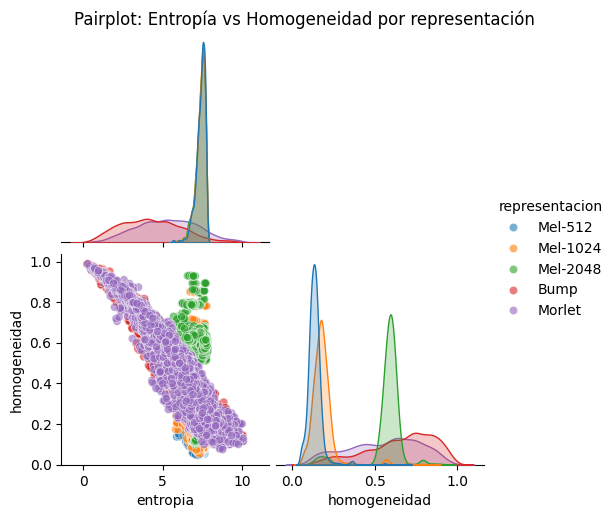

In [111]:
sns.pairplot(
    df,
    vars=['entropia', 'homogeneidad'],
    hue='representacion',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Pairplot: Entropía vs Homogeneidad por representación', y=1.02)
plt.show()

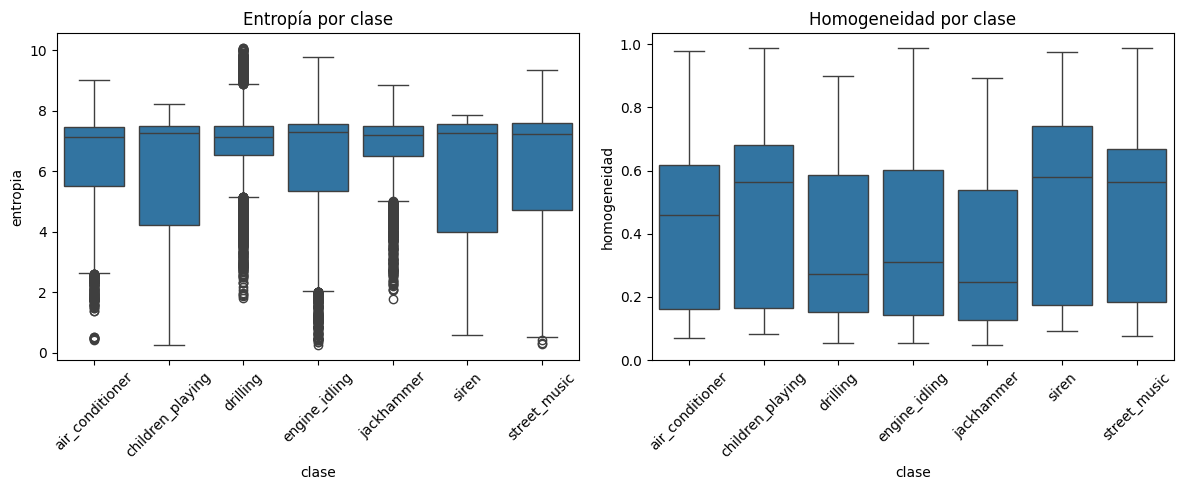

In [112]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='clase', y='entropia')
plt.title('Entropía por clase')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='clase', y='homogeneidad')
plt.title('Homogeneidad por clase')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

c:\Users\pablo\miniconda3\envs\mi_entorno\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


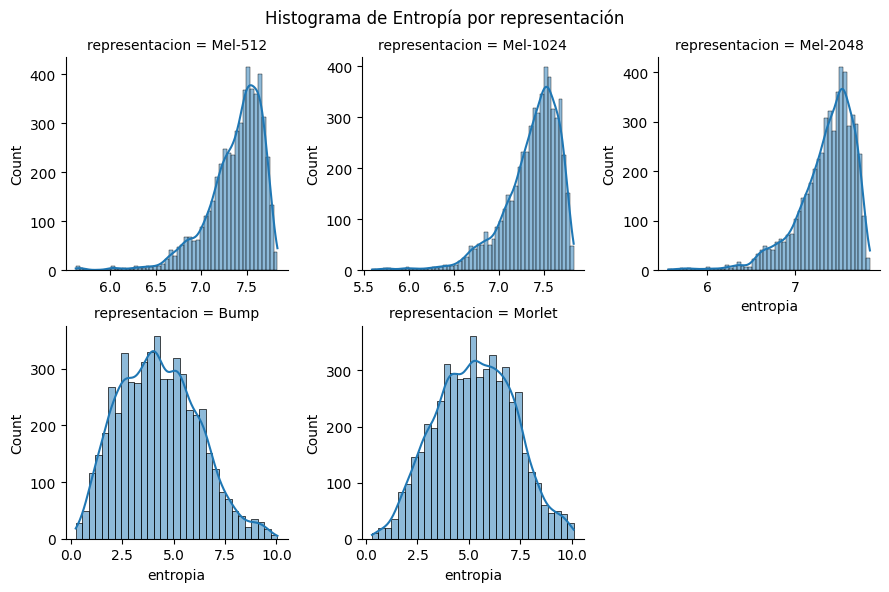

c:\Users\pablo\miniconda3\envs\mi_entorno\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


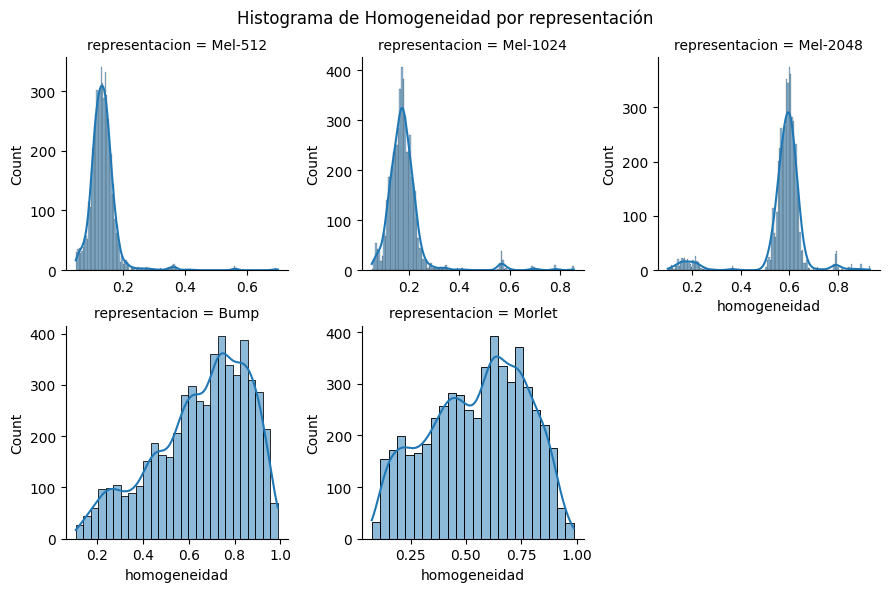

In [113]:
g1 = sns.FacetGrid(df, col='representacion', col_wrap=3, sharex=False, sharey=False)
g1.map(sns.histplot, 'entropia', kde=True)
g1.fig.subplots_adjust(top=0.9)
g1.fig.suptitle('Histograma de Entropía por representación')
plt.show()

# Histograma de homogeneidad
g2 = sns.FacetGrid(df, col='representacion', col_wrap=3, sharex=False, sharey=False)
g2.map(sns.histplot, 'homogeneidad', kde=True)
g2.fig.subplots_adjust(top=0.9)
g2.fig.suptitle('Histograma de Homogeneidad por representación')
plt.show()

c:\Users\pablo\miniconda3\envs\mi_entorno\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


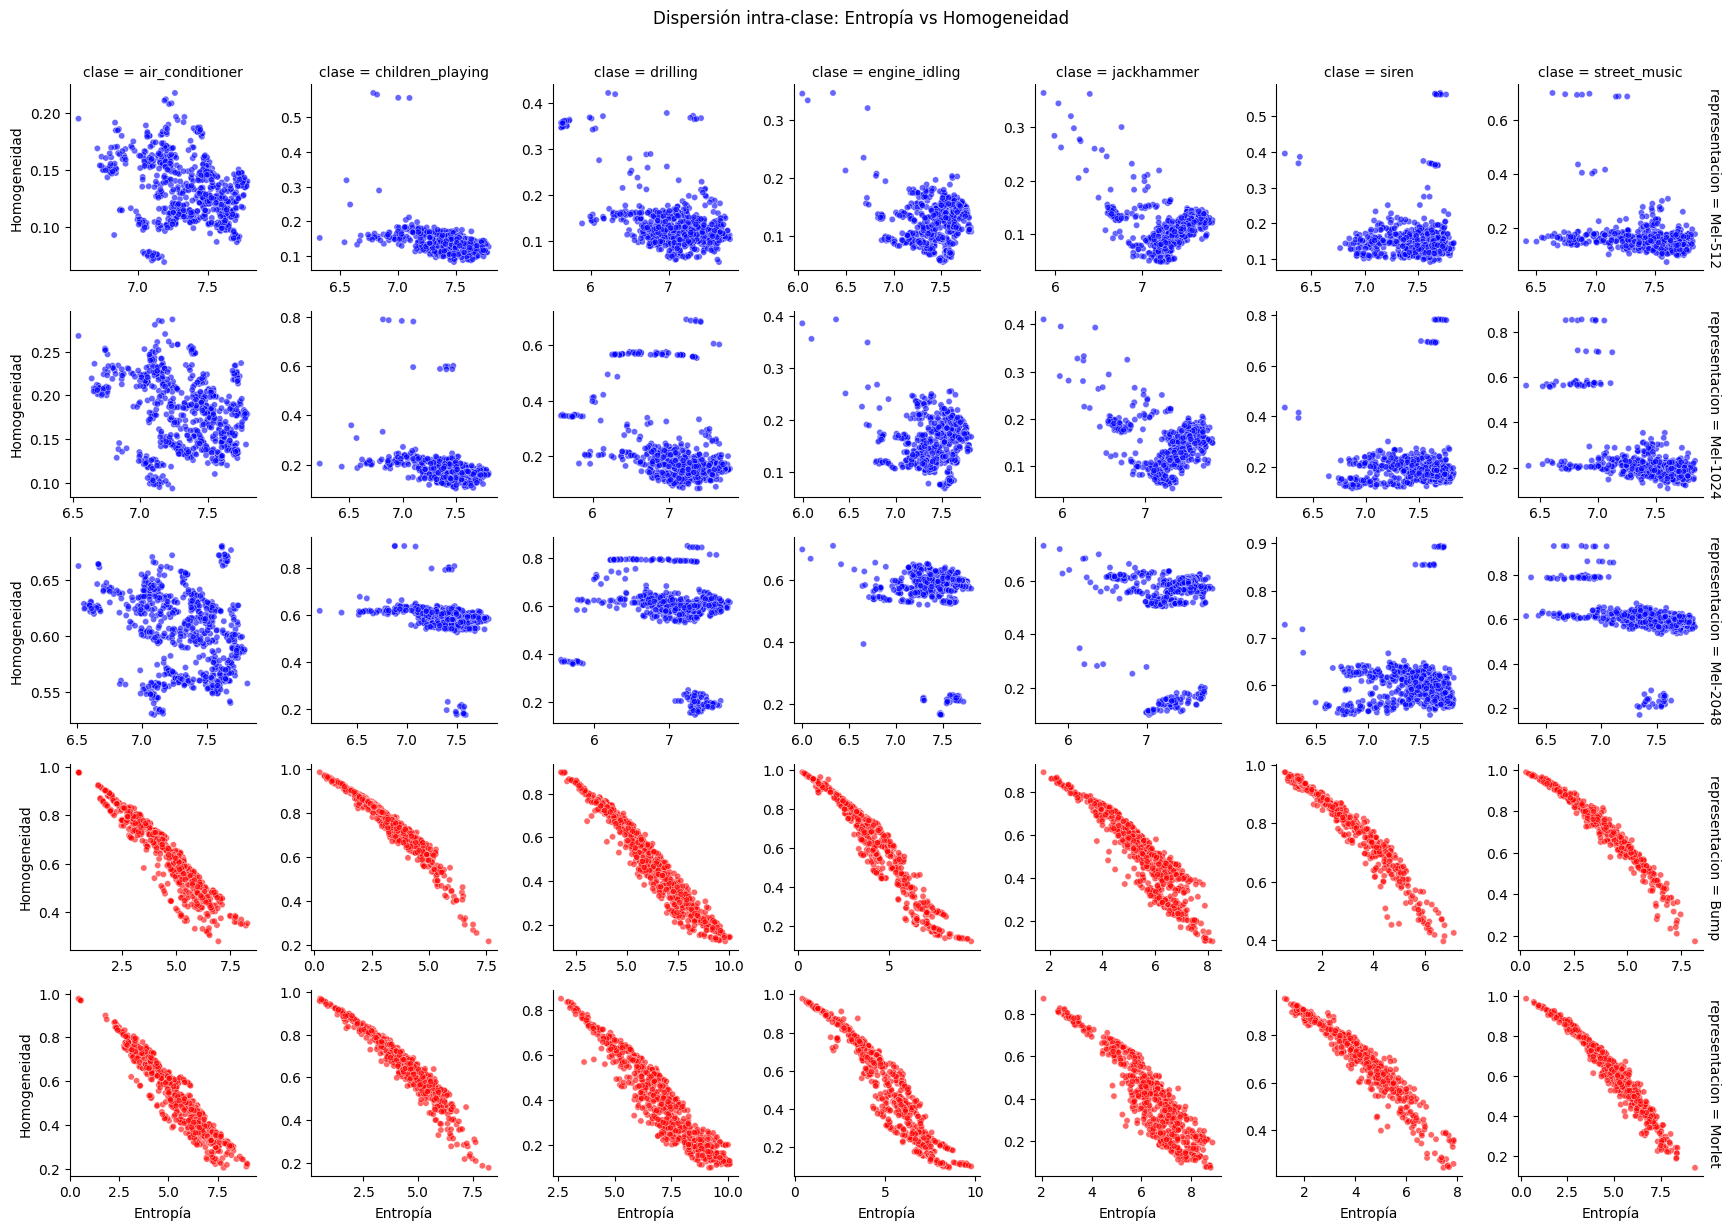

In [114]:
df['color'] = df['representacion'].apply(lambda x: 'red' if x in ['Bump', 'Morlet'] else 'blue')

g = sns.FacetGrid(
    df,
    row='representacion',
    col='clase',
    margin_titles=True,
    sharex=False,
    sharey=False,
    height=2.5
)
g.map_dataframe(sns.scatterplot, 'entropia', 'homogeneidad', alpha=0.6, s=20, hue='color', palette={'red':'red','blue':'blue'}, legend=False)
g.set_axis_labels('Entropía', 'Homogeneidad')
plt.subplots_adjust(top=0.92)
g.fig.suptitle('Dispersión intra-clase: Entropía vs Homogeneidad')
g.fig.savefig(
    'dispersion_intraclase_entropia_homogeneidad.png',
    format='png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [20]:
import os
import shutil
from pathlib import Path

# Mapear nombre corto -> Path completo
repr_paths = { Path(p).name: Path(p) for p in representaciones }

# Directorios de salida
base_selected = Path("DataSetImages_Filtered/Selected")
base_removed  = Path("DataSetImages_Filtered/Removed")
for d in (base_selected, base_removed):
    d.mkdir(parents=True, exist_ok=True)

min_per_class = 500

# 1) Repite tu lógica de ordenamiento / scoring para obtener `selected` y `removed`
#    Aquí asumo que ya tienes un df con las columnas ['representacion','clase','filename',…]
for repr_name, df_repr in df.groupby('representacion'):
    orig_repr_path = repr_paths[repr_name]  # ruta real en disco
    for clase, df_clase in df_repr.groupby('clase'):
        total = len(df_clase)
        if total <= min_per_class:
            selected = df_clase
            removed  = df_clase.iloc[0:0]
        else:
            # ejemplo con score combinado (puedes cambiar por tu criterio)
            df_clase = df_clase.copy()
            # normalización min-max
            df_clase['e_norm'] = (
                (df_clase['entropia'] - df_clase['entropia'].min()) /
                (df_clase['entropia'].max() - df_clase['entropia'].min())
            )
            df_clase['h_norm'] = (
                (df_clase['homogeneidad'] - df_clase['homogeneidad'].min()) /
                (df_clase['homogeneidad'].max() - df_clase['homogeneidad'].min())
            )
            alpha = 0.7
            df_clase['score'] = df_clase['e_norm'] * alpha - df_clase['h_norm'] * (1-alpha)
            
            df_sorted = df_clase.sort_values('score', ascending=False)
            selected = df_sorted.iloc[:min_per_class]
            removed  = df_sorted.iloc[min_per_class:]

        # 2) Crea carpetas de salida por representación y clase
        sel_dir = base_selected / repr_name / clase
        rem_dir = base_removed  / repr_name / clase
        sel_dir.mkdir(parents=True, exist_ok=True)
        rem_dir.mkdir(parents=True, exist_ok=True)

        # 3) Copia usando la ruta completa `orig_repr_path`
        for fname in selected['filename']:
            src = orig_repr_path / clase / fname
            dst = sel_dir / fname
            shutil.copy(src, dst)

        for fname in removed['filename']:
            src = orig_repr_path / clase / fname
            dst = rem_dir / fname
            shutil.copy(src, dst)

print("✔️ Selección y copia completadas.")

✔️ Selección y copia completadas.


In [24]:
representaciones_500 = [
    "DataSetImages_Filtered/Selected/Mel-512",
    "DataSetImages_Filtered/Selected/Mel-1024",
    "DataSetImages_Filtered/Selected/Mel-2048",
    "DataSetImages_Filtered/Selected/Bump",
    "DataSetImages_Filtered/Selected/Morlet"
]

In [25]:
records2 = []

for ruta_repr in representaciones_500:
    repr_name = os.path.basename(ruta_repr)
    print(f" Procesando representación: {repr_name}")
    for clase in clases:
        carpeta = os.path.join(ruta_repr, clase)
        imagenes = os.listdir(carpeta)[:]  # primeros 100 para prueba
        for fname in imagenes:
            img = imread(os.path.join(carpeta, fname), as_gray=True)
            records2.append({
                'representacion_500': repr_name,
                'clase_500': clase,
                'filename_500': fname,
                'entropia_500': calcular_entropia(img),
                'homogeneidad_500': calcular_homogeneidad(img)
            })

df = pd.DataFrame(records2)
print(f"\nTotal de imágenes procesadas: {len(df)}")

🔍 Procesando representación: Mel-512
🔍 Procesando representación: Mel-1024
🔍 Procesando representación: Mel-2048
🔍 Procesando representación: Bump
🔍 Procesando representación: Morlet

Total de imágenes procesadas: 17500


In [ ]:
resumen_500 = df.groupby(
    ['representacion_500', 'clase_500']
)[['entropia_500', 'homogeneidad_500']].agg(['min', 'max', 'mean', 'std'])
display(resumen_500)

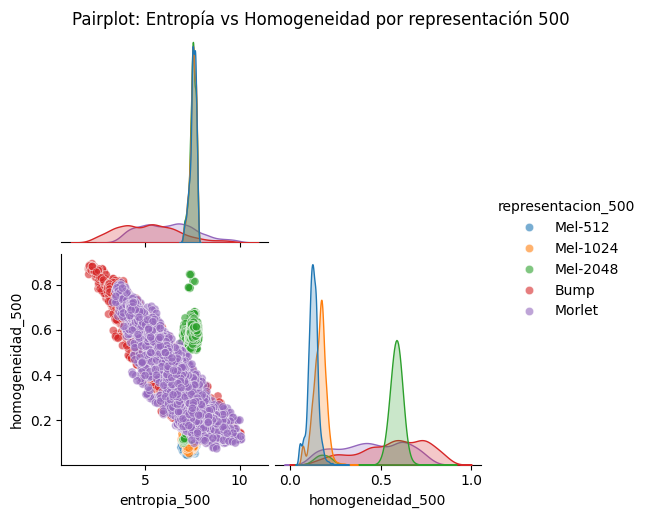

In [27]:
sns.pairplot(
    df,
    vars=['entropia_500', 'homogeneidad_500'],
    hue='representacion_500',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Pairplot: Entropía vs Homogeneidad por representación 500', y=1.02)
plt.show()

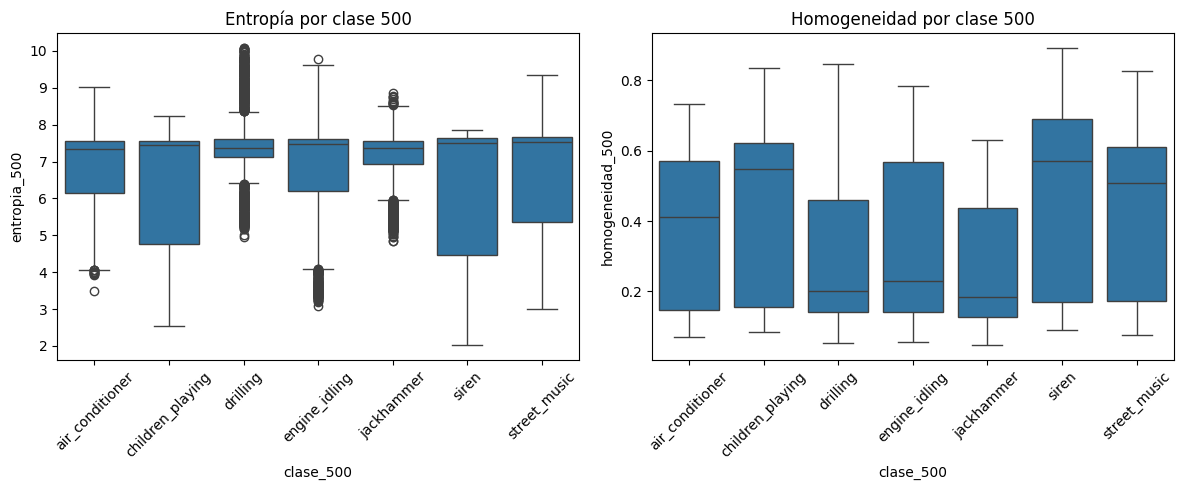

In [28]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='clase_500', y='entropia_500')
plt.title('Entropía por clase 500')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='clase_500', y='homogeneidad_500')
plt.title('Homogeneidad por clase 500')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

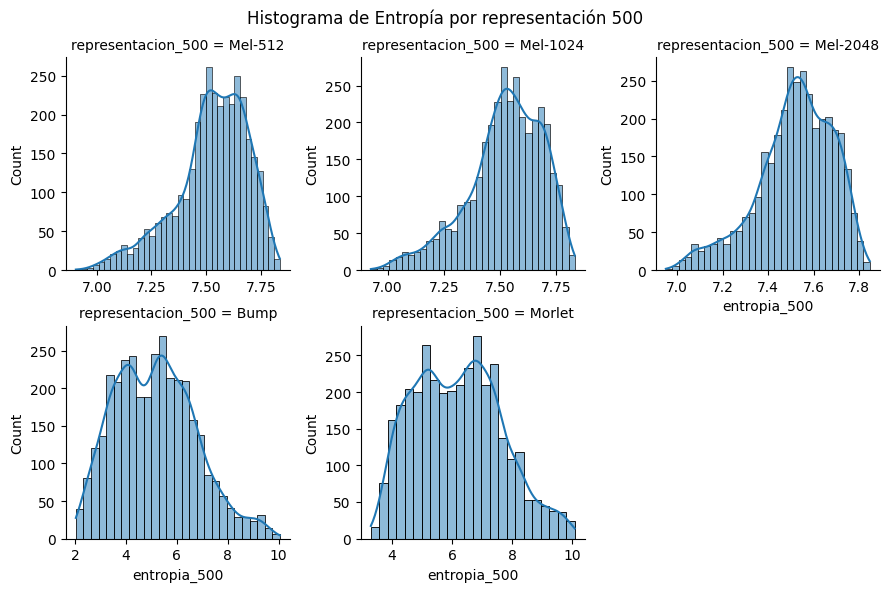

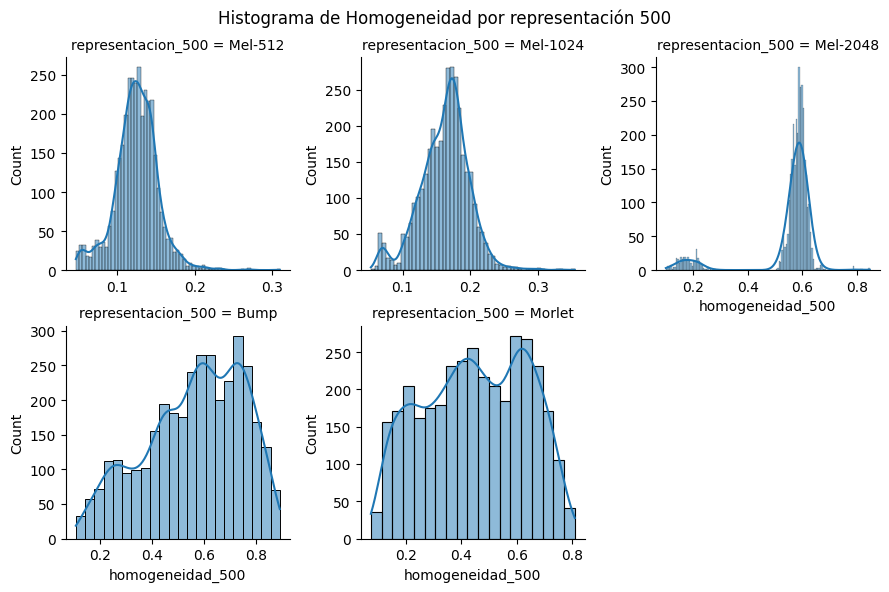

In [29]:
g1 = sns.FacetGrid(df, col='representacion_500', col_wrap=3, sharex=False, sharey=False)
g1.map(sns.histplot, 'entropia_500', kde=True)
g1.fig.subplots_adjust(top=0.9)
g1.fig.suptitle('Histograma de Entropía por representación 500')
plt.show()

# Histograma de homogeneidad
g2 = sns.FacetGrid(df, col='representacion_500', col_wrap=3, sharex=False, sharey=False)
g2.map(sns.histplot, 'homogeneidad_500', kde=True)
g2.fig.subplots_adjust(top=0.9)
g2.fig.suptitle('Histograma de Homogeneidad por representación 500')
plt.show()

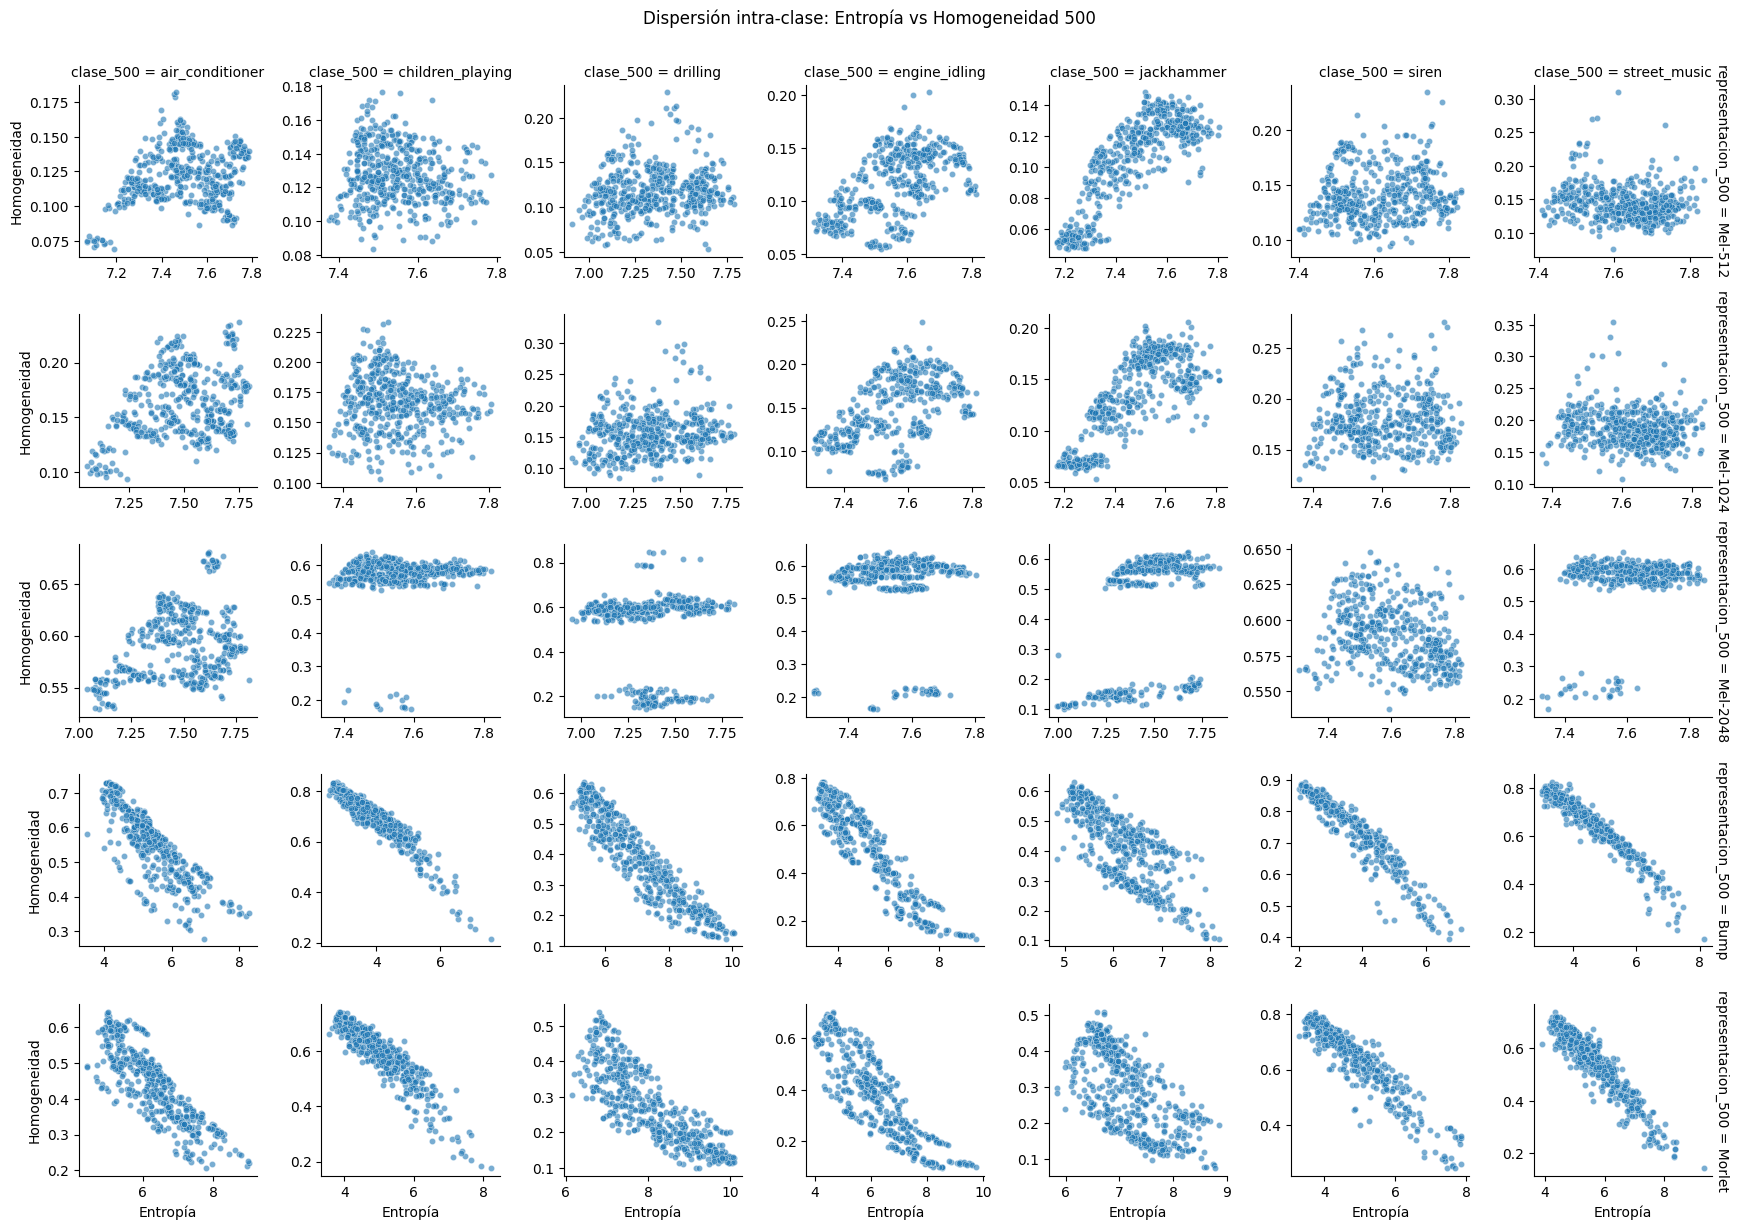

In [30]:
# Asignacion de color de representacion
df['color'] = df['representacion'].apply(lambda x: 'red' if x in ['Bump', 'Morlet'] else 'blue')

g = sns.FacetGrid(
    df,
    row='representacion_500',
    col='clase_500',
    margin_titles=True,
    sharex=False,
    sharey=False,
    height=2.5
)
g.map_dataframe(sns.scatterplot, 'entropia_500', 'homogeneidad_500', alpha=0.6, s=20)
g.set_axis_labels('Entropía', 'Homogeneidad')
plt.subplots_adjust(top=0.92)
g.fig.suptitle('Dispersión intra-clase: Entropía vs Homogeneidad 500')
g.fig.savefig(
    'dispersion_intraclase_entropia_homogeneidad-500.png',
    format='png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [43]:
from pathlib import Path
import pandas as pd
from skimage.io import imread
representaciones_500_removed = [
    "DataSetImages_Filtered/Removed/Mel-512",
    "DataSetImages_Filtered/Removed/Mel-1024",
    "DataSetImages_Filtered/Removed/Mel-2048",
    "DataSetImages_Filtered/Removed/Bump",
    "DataSetImages_Filtered/Removed/Morlet"
]


In [44]:
records3 = []
for ruta_repr in representaciones_500_removed:
    repr_path = Path(ruta_repr)
    repr_name = repr_path.name
    print(f" Procesando representación: {repr_name}")
    
    for clase in clases:
        carpeta = repr_path / clase
        # Solo ficheros, descartar subcarpetas
        imagen_paths = [p for p in carpeta.iterdir() if p.is_file()]
        
        for img_path in imagen_paths:
            img = imread(str(img_path), as_gray=True)
            records3.append({
                'representacion_500_removed': repr_name,
                'clase_500_removed': clase,
                'filename_500_removed': img_path.name,
                'entropia_500_removed': calcular_entropia(img),
                'homogeneidad_500_removed': calcular_homogeneidad(img)
            })

# Ahora sí construimos el DataFrame con records3
df_removed = pd.DataFrame(records3)
print(f"\nTotal de imágenes procesadas en Removed: {len(df_removed)}")


🔍 Procesando representación: Mel-512
🔍 Procesando representación: Mel-1024
🔍 Procesando representación: Mel-2048
🔍 Procesando representación: Bump
🔍 Procesando representación: Morlet

Total de imágenes procesadas en Removed: 9310


In [47]:
resumen_500_removed = df_removed.groupby(
    ['representacion_500_removed', 'clase_500_removed']
)[['entropia_500_removed', 'homogeneidad_500_removed']].agg(['min', 'max', 'mean', 'std'])
display(resumen_500_removed)

entropia_500_removed            \
                                                              min       max   
representacion_500_removed clase_500_removed                                  
Bump                       air_conditioner               0.466923  4.038622   
                           children_playing              0.241702  2.639143   
                           drilling                      1.791381  5.338170   
                           engine_idling                 0.250700  3.363464   
                           jackhammer                    1.766023  5.152751   
                           siren                         0.581912  2.080854   
                           street_music                  0.302776  3.096980   
Mel-1024                   air_conditioner               6.543995  7.410256   
                           children_playing              6.220584  7.475361   
                           drilling                      5.586572  7.650866   
                           engine_idling                 5.995060  7.597783   
                           jackhammer                    5.765321  7.435875   
                           siren                         6.231528  7.762102   
                           street_music                  6.378071  7.468603   
Mel-2048                   air_conditioner               6.513062  7.360112   
                           children_playing              6.124243  7.476550   
                           drilling                      5.555221  7.318362   
                           engine_idling                 6.004785  7.424641   
                           jackhammer                    5.690007  7.340373   
                           siren                         6.205849  7.726255   
                           street_music                  6.322814  7.442423   
Mel-512                    air_conditioner               6.569984  7.447113   
                           children_playing              6.325035  7.461996   
                           drilling                      5.622515  7.415567   
                           engine_idling                 6.043451  7.612242   
                           jackhammer                    5.866484  7.346826   
                           siren                         6.252098  7.760995   
                           street_music                  6.413881  7.558827   
Morlet                     air_conditioner               0.416753  4.968109   
                           children_playing              0.499419  3.823394   
                           drilling                      2.615278  6.700514   
                           engine_idling                 0.404494  4.363268   
                           jackhammer                    2.068629  6.448821   
                           siren                         1.233956  3.531907   
                           street_music                  0.291476  4.305983   

                                                                  \
                                                  mean       std   
representacion_500_removed clase_500_removed                       
Bump                       air_conditioner    2.763120  0.755830   
                           children_playing   1.838976  0.572521   
                           drilling           3.960099  0.855482   
                           engine_idling      1.991972  0.790733   
                           jackhammer         4.123572  0.799417   
                           siren              1.490319  0.367855   
                           street_music       2.140674  0.653476   
Mel-1024                   air_conditioner    7.061808  0.195775   
                           children_playing   7.196565  0.225217   
                           drilling           6.704532  0.405212   
                           engine_idling      7.206341  0.224396   
                           jackhammer         7.006272  0.305606   
                      

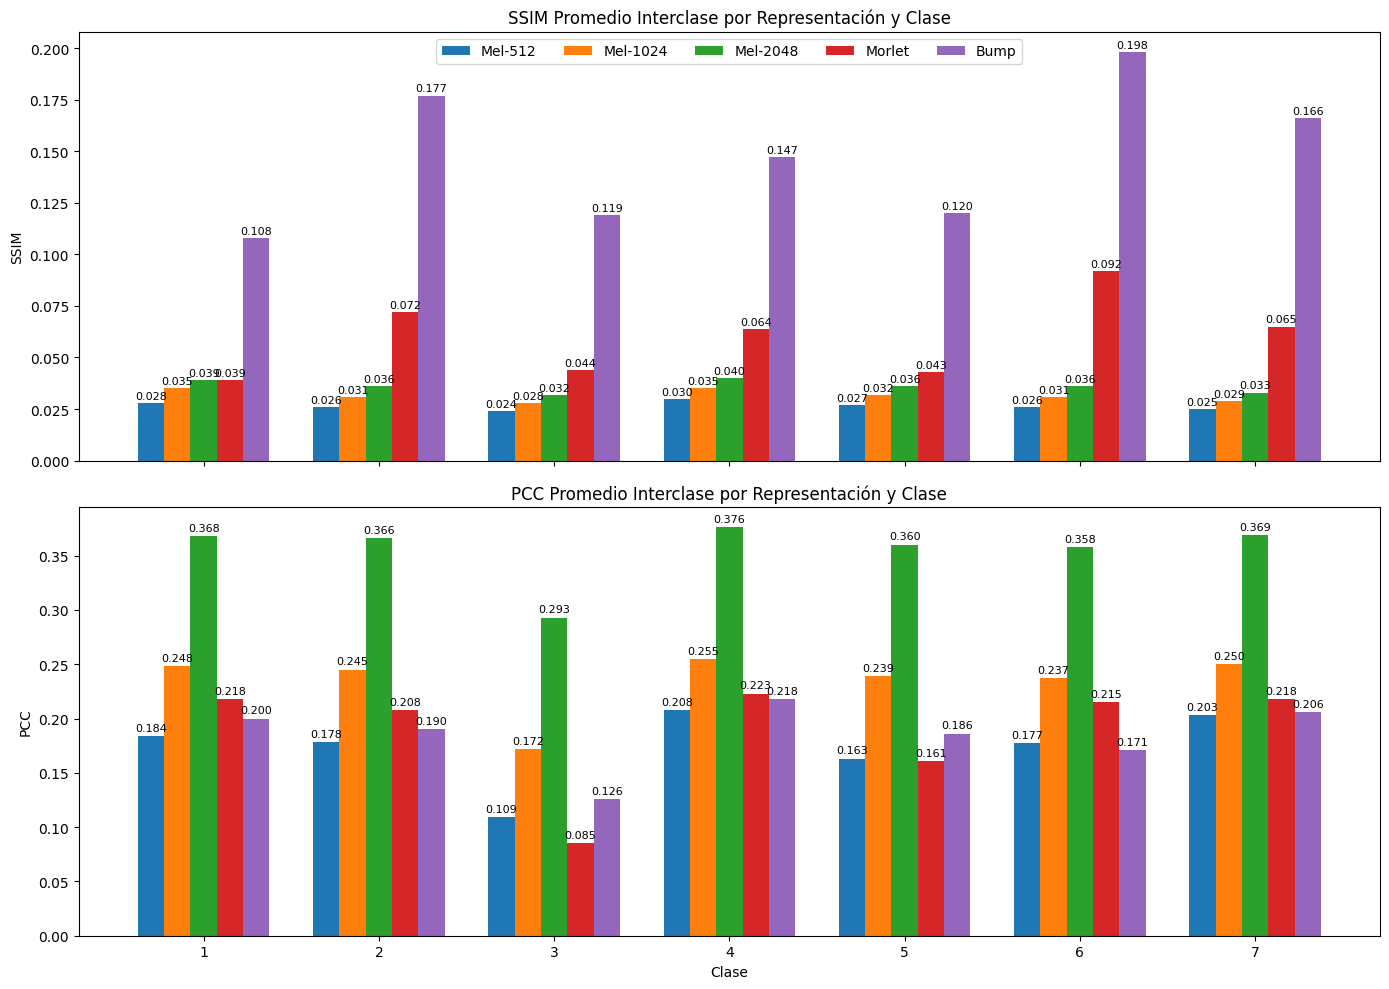

In [123]:
import matplotlib.pyplot as plt
import numpy as np

# Datos por clase para cada representación
clases = np.arange(1, 8)
ssim_mel_512 = [0.028, 0.026, 0.024, 0.030, 0.027, 0.026, 0.025]
ssim_mel_1024 = [0.035, 0.031, 0.028, 0.035, 0.032, 0.031, 0.029]
ssim_mel_2048 = [0.039, 0.036, 0.032, 0.040, 0.036, 0.036, 0.033]
ssim_morlet = [0.039, 0.072, 0.044, 0.064, 0.043, 0.092, 0.065]
ssim_bump = [0.108, 0.177, 0.119, 0.147, 0.120, 0.198, 0.166]

pcc_mel_512 = [0.184, 0.178, 0.109, 0.208, 0.163, 0.177, 0.203]
pcc_mel_1024 = [0.248, 0.245, 0.172, 0.255, 0.239, 0.237, 0.250]
pcc_mel_2048 = [0.368, 0.366, 0.293, 0.376, 0.360, 0.358, 0.369]
pcc_morlet = [0.218, 0.208, 0.085, 0.223, 0.161, 0.215, 0.218]
pcc_bump = [0.200, 0.190, 0.126, 0.218, 0.186, 0.171, 0.206]

# Agrupar los datos
ssim_data = [ssim_mel_512, ssim_mel_1024, ssim_mel_2048, ssim_morlet, ssim_bump]
pcc_data = [pcc_mel_512, pcc_mel_1024, pcc_mel_2048, pcc_morlet, pcc_bump]
labels = ['Mel-512', 'Mel-1024', 'Mel-2048', 'Morlet', 'Bump']
patterns = ['--', '--', '--', '--', '--']

x = np.arange(len(clases))  # posiciones de las clases
width = 0.15  # ancho de cada barra

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# SSIM
for i, (ssim, label, pattern) in enumerate(zip(ssim_data, labels, patterns)):
    rects = ax1.bar(x + i * width, ssim, width, label=label)   # , hatch=pattern
    for rect in rects:
        height = rect.get_height()
        ax1.text(rect.get_x() + rect.get_width() / 2, height + 0.001, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=8)

ax1.set_title('SSIM Promedio Interclase por Representación y Clase')
ax1.set_ylabel('SSIM')
ax1.legend(loc='upper center', ncol=5)

# PCC
for i, (pcc, label, pattern) in enumerate(zip(pcc_data, labels, patterns)):
    rects = ax2.bar(x + i * width, pcc, width, label=label)  # , hatch=pattern
    for rect in rects:
        height = rect.get_height()
        ax2.text(rect.get_x() + rect.get_width() / 2, height + 0.003, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=8)

ax2.set_title('PCC Promedio Interclase por Representación y Clase')
ax2.set_ylabel('PCC')
ax2.set_xlabel('Clase')
ax2.set_xticks(x + 2 * width)
ax2.set_xticklabels([str(c) for c in clases], size)
plt.savefig(
    'diagrama_barras.png',
    format='png',
    dpi=300,
    bbox_inches='tight'
)
plt.tight_layout()
plt.show()


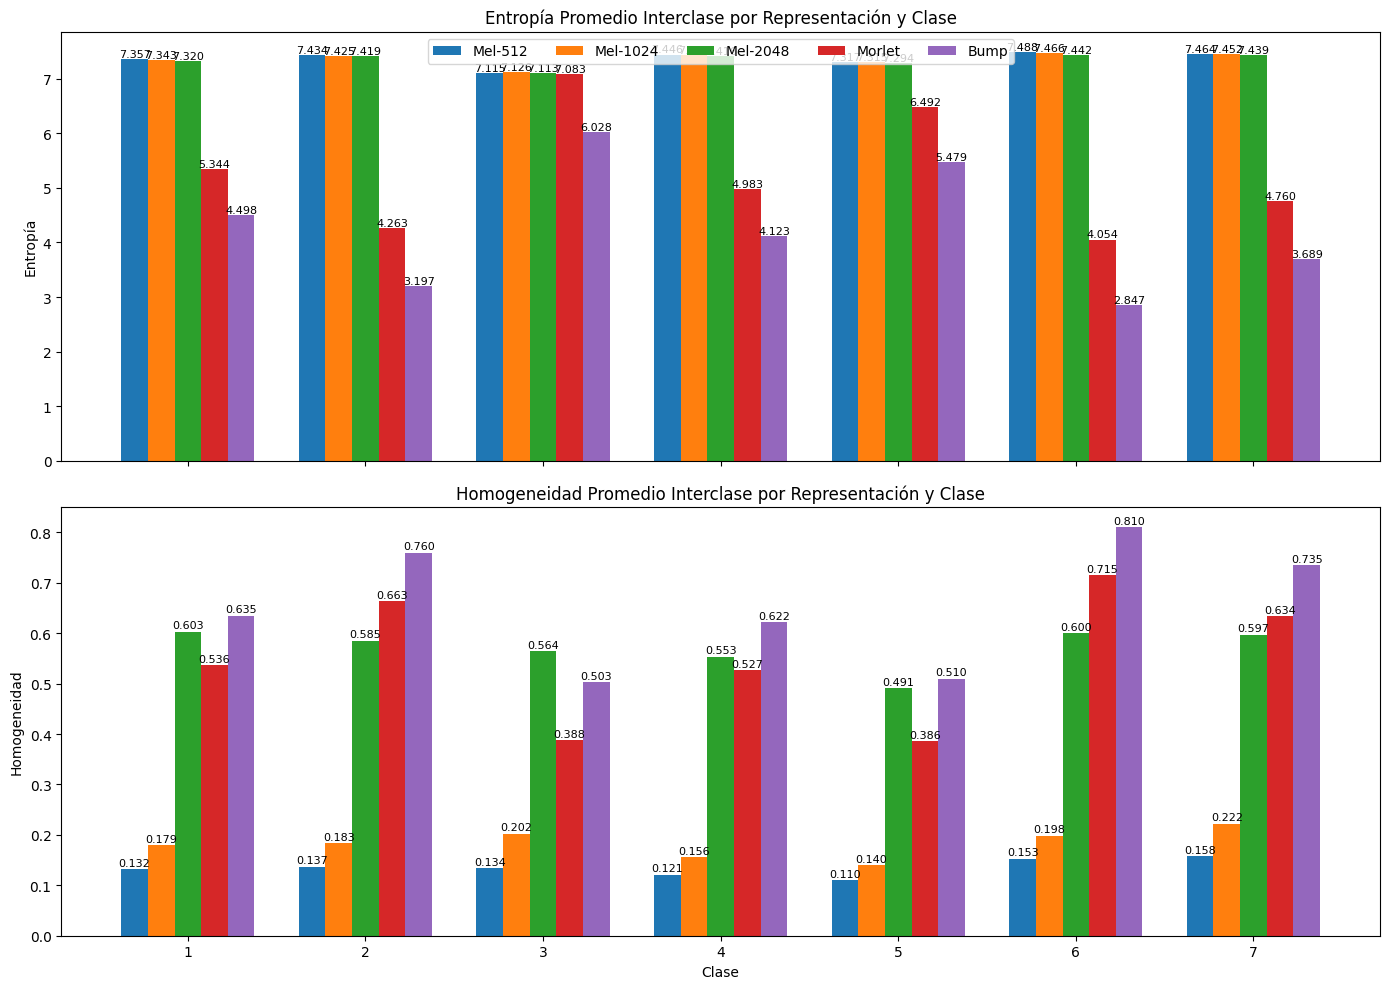

In [127]:
## Diagrama de barras para Entropia y Homogeneidad
import matplotlib.pyplot as plt
import numpy as np

# Datos por clase para cada representación
clases = np.arange(1, 8)

entropy_mel_512 = [7.357,7.434,7.115,7.446,7.317,7.488,7.464]
entropy_mel_1024 = [7.343,7.425,7.126,7.438,7.315,7.466,7.452]
entropy_mel_2048 = [7.320,7.419,7.113,7.416,7.294,7.442,7.439]
entropy_morlet = [5.344,4.263,7.083,4.983,6.492,4.054,4.760]
entropy_bump = [4.498,3.197,6.028,4.123,5.479,2.847,3.689]

homo_mel_512 = [0.132,0.137,0.134,0.121,0.110,0.153,0.158]
homo_mel_1024 = [0.179,0.183,0.202,0.156,0.14,0.198,0.222]
homo_mel_2048 = [0.603,0.585,0.564,0.553,0.491,0.60,0.597]
homo_morlet = [0.536,0.663,0.388,0.527,0.386,0.715,0.634]
homo_bump = [0.635,0.760,0.503,0.622,0.510,0.810,0.735]

# Agrupar los datos
entropy_data = [entropy_mel_512, entropy_mel_1024, entropy_mel_2048, entropy_morlet, entropy_bump]
homo_data = [homo_mel_512, homo_mel_1024, homo_mel_2048, homo_morlet, homo_bump]
labels = ['Mel-512', 'Mel-1024', 'Mel-2048', 'Morlet', 'Bump']
patterns = ['--', '--', '--', '--', '--']

x = np.arange(len(clases))  # posiciones de las clases
width = 0.15  # ancho de cada barra

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Entropia
for i, (entropy, label, pattern) in enumerate(zip(entropy_data, labels, patterns)):
    rects = ax1.bar(x + i * width, entropy, width, label=label)   # , hatch=pattern
    for rect in rects:
        height = rect.get_height()
        ax1.text(rect.get_x() + rect.get_width() / 2, height + 0.001, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=8)

ax1.set_title('Entropía Promedio Interclase por Representación y Clase')
ax1.set_ylabel('Entropía')
ax1.legend(loc='upper center', ncol=5)

# PCC
for i, (homo, label, pattern) in enumerate(zip(homo_data, labels, patterns)):
    rects = ax2.bar(x + i * width, homo, width, label=label)  # , hatch=pattern
    for rect in rects:
        height = rect.get_height()
        ax2.text(rect.get_x() + rect.get_width() / 2, height + 0.003, f'{height:.3f}',
                 ha='center', va='bottom', fontsize=8)

ax2.set_title('Homogeneidad Promedio Interclase por Representación y Clase')
ax2.set_ylabel('Homogeneidad')
ax2.set_xlabel('Clase')
ax2.set_xticks(x + 2 * width)
ax2.set_xticklabels([str(c) for c in clases])
plt.savefig(
    'diagrama_barras_intraclase.png',
    format='png',
    dpi=300,
    bbox_inches='tight'
)
plt.tight_layout()
plt.show()

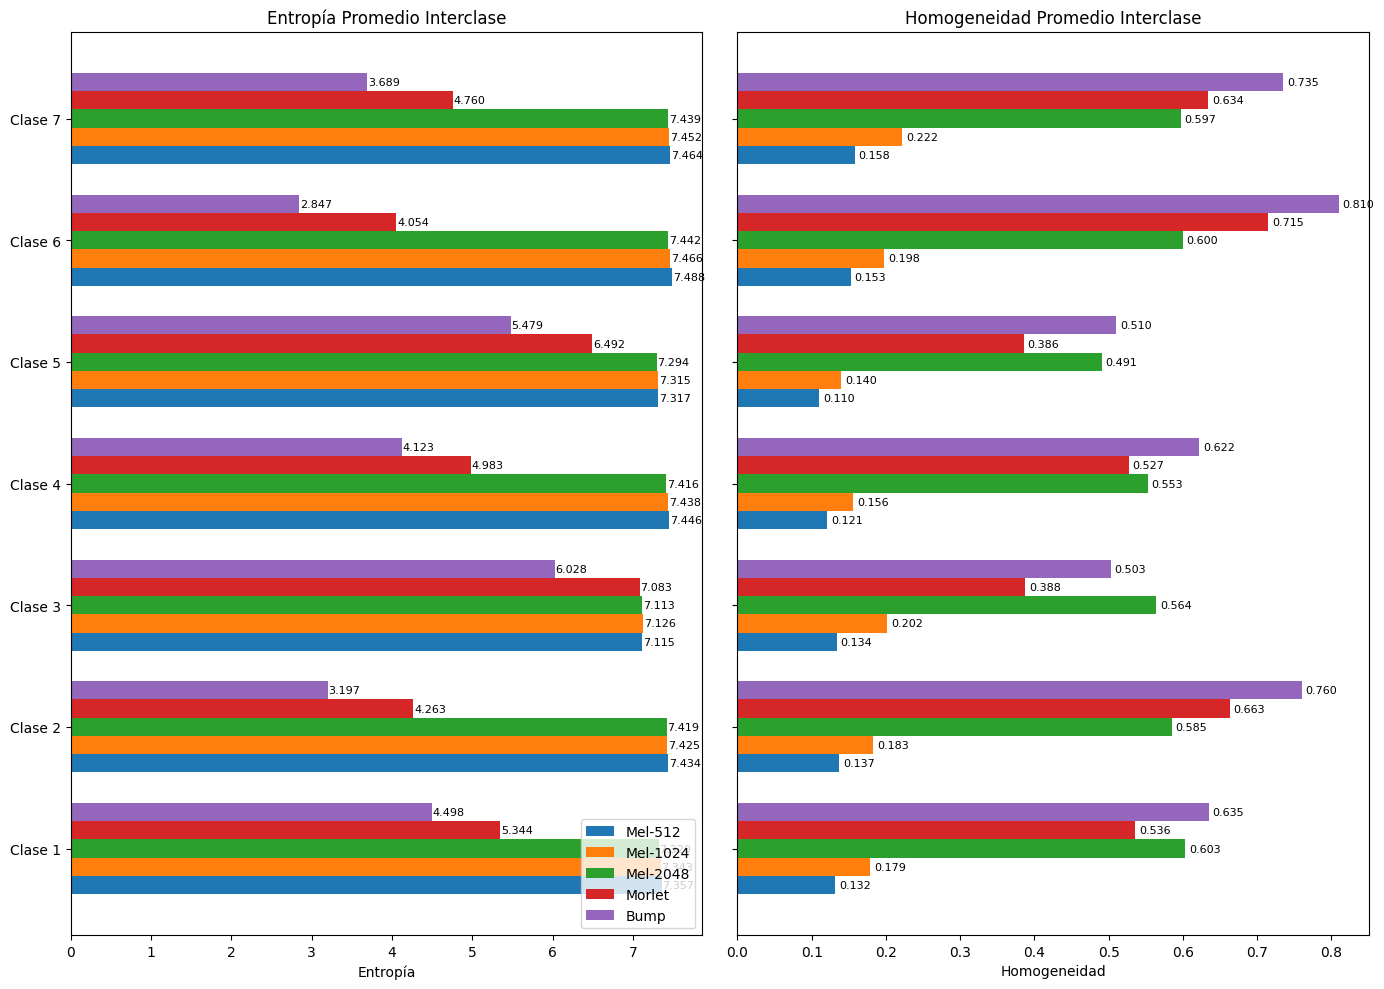

In [128]:
import matplotlib.pyplot as plt
import numpy as np

# Datos por clase para cada representación
clases = np.arange(1, 8)

entropy_mel_512 = [7.357,7.434,7.115,7.446,7.317,7.488,7.464]
entropy_mel_1024 = [7.343,7.425,7.126,7.438,7.315,7.466,7.452]
entropy_mel_2048 = [7.320,7.419,7.113,7.416,7.294,7.442,7.439]
entropy_morlet = [5.344,4.263,7.083,4.983,6.492,4.054,4.760]
entropy_bump = [4.498,3.197,6.028,4.123,5.479,2.847,3.689]

homo_mel_512 = [0.132,0.137,0.134,0.121,0.110,0.153,0.158]
homo_mel_1024 = [0.179,0.183,0.202,0.156,0.14,0.198,0.222]
homo_mel_2048 = [0.603,0.585,0.564,0.553,0.491,0.60,0.597]
homo_morlet = [0.536,0.663,0.388,0.527,0.386,0.715,0.634]
homo_bump = [0.635,0.760,0.503,0.622,0.510,0.810,0.735]

# Agrupar los datos
entropy_data = [entropy_mel_512, entropy_mel_1024, entropy_mel_2048, entropy_morlet, entropy_bump]
homo_data = [homo_mel_512, homo_mel_1024, homo_mel_2048, homo_morlet, homo_bump]
labels = ['Mel-512', 'Mel-1024', 'Mel-2048', 'Morlet', 'Bump']

y = np.arange(len(clases))  # posiciones de las clases
height = 0.15  # altura de cada barra

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10), sharey=True)

# Entropía (barras horizontales)
for i, (entropy, label) in enumerate(zip(entropy_data, labels)):
    rects = ax1.barh(y + i * height, entropy, height, label=label)
    for rect in rects:
        width = rect.get_width()
        ax1.text(width + 0.01, rect.get_y() + rect.get_height() / 2, f'{width:.3f}',
                 va='center', fontsize=8)

ax1.set_title('Entropía Promedio Interclase')
ax1.set_xlabel('Entropía')
ax1.set_yticks(y + 2 * height)
ax1.set_yticklabels([f'Clase {c}' for c in clases])
ax1.legend(loc='lower right')

# Homogeneidad (barras horizontales)
for i, (homo, label) in enumerate(zip(homo_data, labels)):
    rects = ax2.barh(y + i * height, homo, height, label=label)
    for rect in rects:
        width = rect.get_width()
        ax2.text(width + 0.005, rect.get_y() + rect.get_height() / 2, f'{width:.3f}',
                 va='center', fontsize=8)

ax2.set_title('Homogeneidad Promedio Interclase')
ax2.set_xlabel('Homogeneidad')

plt.tight_layout()
plt.savefig('diagrama_barras_horizontales.png', dpi=300, bbox_inches='tight')
plt.show()
